In [4]:
import numpy as np
import pandas as pd
import mab_subjects

exps = mab_subjects.mostly_unstruc.allsess + mab_subjects.mostly_struc.allsess

trials_df = []
for e, exp in enumerate(exps):
    # print(f"Experiment {e}: {exp}")
    task = exp.b2a
    task.auto_block_window_ids()
    window_ids = task.window_ids
    ntrials_window = np.unique(window_ids, return_counts=True)[1]

    df = pd.DataFrame(
        {
            "ntrials_per_window": ntrials_window,
            "sub_name": exp.sub_name,
        }
    )
    trials_df.append(df)

trials_df = pd.concat(trials_df, ignore_index=True)

Text(0, 0.5, 'Number of Trials\n per Window')

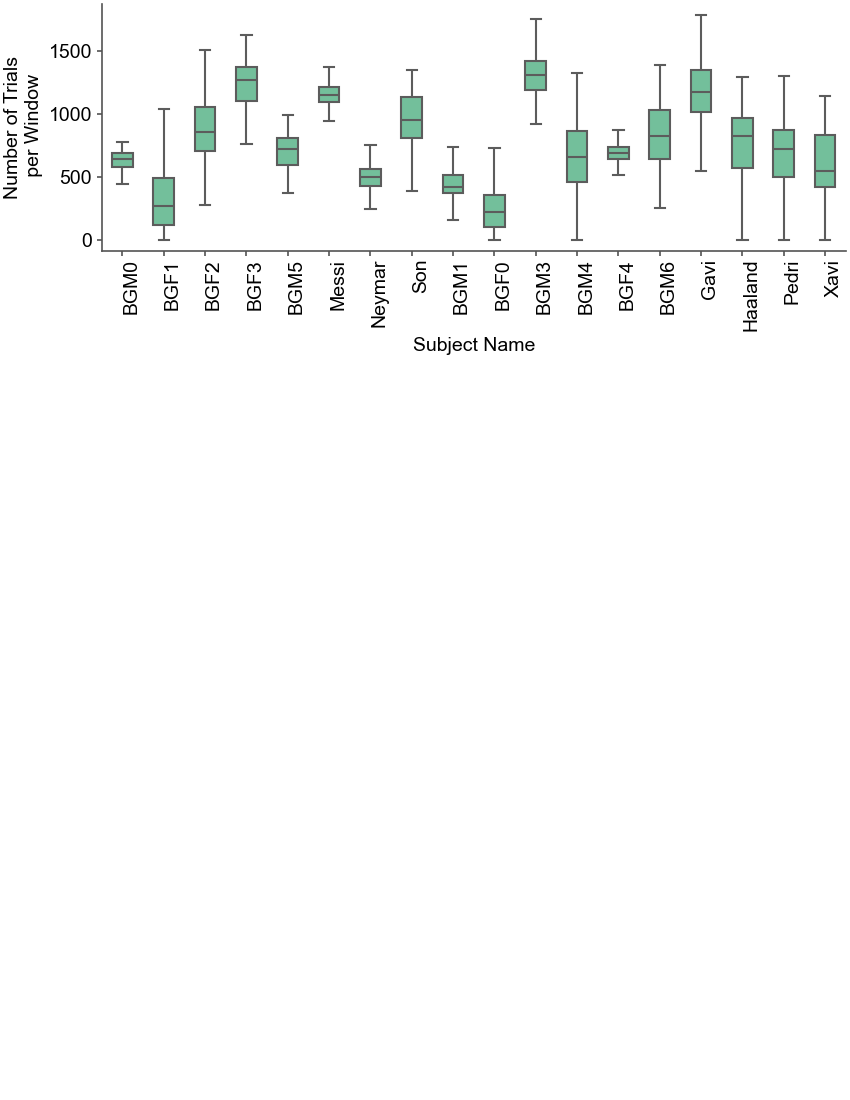

In [ ]:
from statplotannot.plots import Fig, xtick_format
import seaborn as sns


fig = Fig(4, 1, fontsize=14)

ax = fig.subplot(fig.gs[0])
sns.boxplot(
    data=trials_df,
    x="sub_name",
    y="ntrials_per_window",
    showfliers=False,
    ax=ax,
    color="#66cc9b",
    width=0.5,
    # saturation=0.5,
    linewidth=1.5,
)
xtick_format(ax, rotation=90)
ax.set_xlabel("Subject Name")
ax.set_ylabel("Number of Trials\n per Window")